v0.0.1

In [222]:
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np


In [223]:
import matplotlib.pyplot as plt
import cartopy.mpl.ticker as cticker

In [224]:
# membuka dataset
ds1 = xr.open_dataset('cmems_mod_glo_phy-cur_anfc_0.083deg_P1M-m_1760332077670.nc')

ds2 = xr.open_dataset('cmems_mod_glo_phy-thetao_anfc_0.083deg_P1M-m_1760331904586.nc')

# ds3 = xr.open_dataset('Current 2024 February.nc')

# ds4 = xr.open_dataset('Temp 2024 February.nc')

In [225]:
step = 2 # Ambil setiap 10 titik

In [226]:
lon_quiver = ds1.longitude
lat_quiver = ds1.latitude

uo_values = ds1.uo.sel(time=ds1.time[0], depth=ds1.depth[0])
vo_values = ds1.vo.sel(time=ds1.time[0], depth=ds1.depth[0])

uo = uo_values[::step, ::step]
vo = vo_values [::step, ::step]


# Ambil koordinat
lon =  np.meshgrid(lon_quiver[::step])
lat =  np.meshgrid(lat_quiver[::step])

lon = np.array(lon)
lat = np.array(lat)


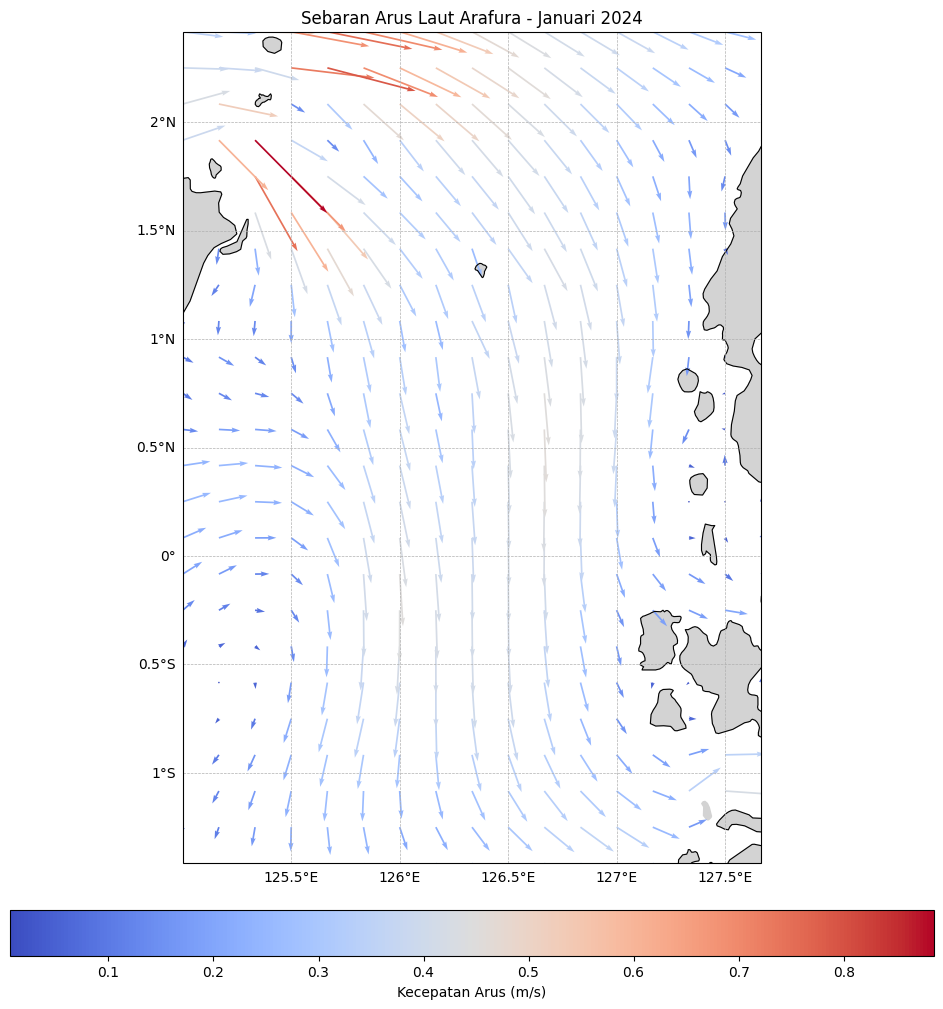

In [227]:
# Hitung magnitudo kecepatan arus
speed = np.sqrt(uo**2 + vo**2)

# Buat plot peta
fig, ax = plt.subplots(figsize=(20, 12), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

# Tambahkan garis pantai dan daratan
ax.add_feature(cfeature.LAND, color="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

# Tambahkan vektor arus laut
q = ax.quiver(lon, lat, uo, vo, speed, scale=5, cmap="coolwarm")

# Tambahkan colorbar untuk kecepatan arus
cbar = fig.colorbar(q, ax=ax, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Kecepatan Arus (m/s)")

    # Tambahkan grid koordinat
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)

    # Hilangkan label di kanan dan atas
gl.right_labels = False
gl.top_labels = False

# Tambahkan judul
plt.title("Sebaran Arus Laut Arafura - Januari 2024")
plt.show()

c:\Users\Hype\AppData\Local\Programs\Python\Python313\Lib\site-packages\cartopy\mpl\geoaxes.py:1646: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


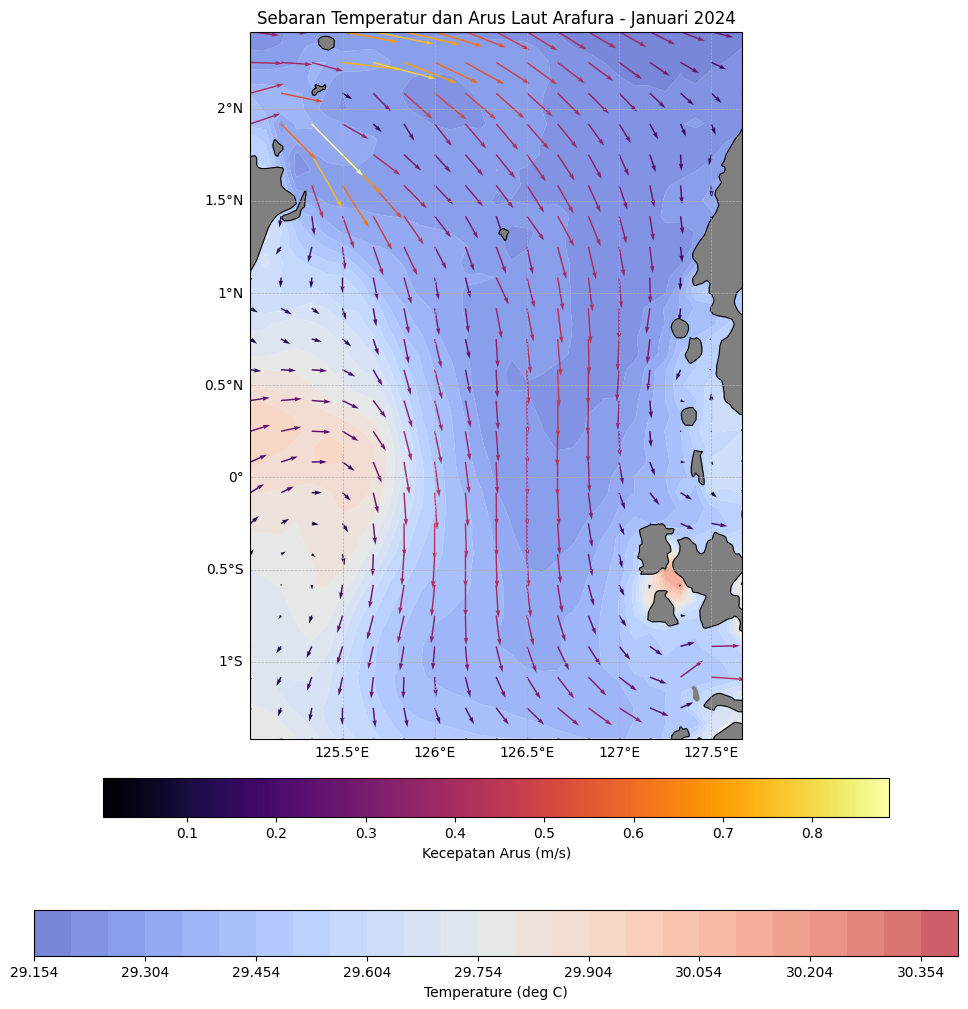

In [228]:

# Menentukan indeks waktu untuk Januari 2020
time_index = 0  # Pastikan ini didefinisikan sebelum digunakan

# Memilih data suhu permukaan laut (depth=0) untuk Januari 2020
t_jan = ds2["thetao"].isel(time=time_index, depth=0)

t_jan = t_jan.interpolate_na(dim="latitude", method="linear")
t_jan = t_jan.interpolate_na(dim="longitude", method="linear")

# Perbaiki Grid 2D
lon2D, lat2D = np.meshgrid(lon_quiver, lat_quiver)

# Plot peta arus dengan Cartopy
fig, ax = plt.subplots(figsize=(20, 12), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

# Tentukan batas bawah dan atas suhu
vmin = float(t_jan.min())
vmax = float(t_jan.max())

# Tambahkan latar belakang kecepatan arus
ax.add_feature(cfeature.NaturalEarthFeature("physical", "land", "10m"), facecolor="gray")
#cmap = ax.pcolormesh(lon2D, lat2D, t_jan, cmap="coolwarm", transform=ccrs.PlateCarree(), alpha=0.7, shading='nearest')
cmap = ax.contourf(lon2D, lat2D, t_jan, cmap="coolwarm", transform=ccrs.PlateCarree(), alpha=0.7, shading='flat', extend='neither' , antialiased='True', levels = np.arange(vmin, vmax + 0.05, 0.05))

# Tambahkan garis pantai dan daratan
ax.add_feature(cfeature.LAND, color="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

# Tambahkan vektor arus laut
q = ax.quiver(lon, lat, uo, vo, speed, scale=6, cmap="inferno")

# Tambahkan colorbar untuk kecepatan arus
cbar = plt.colorbar(cmap, ax=ax, orientation="horizontal", fraction=0.05, pad=0.10)
cbar.set_label("Temperature (deg C)")

cbar = fig.colorbar(q, ax=ax, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Kecepatan Arus (m/s)")


# Tambahkan grid koordinat
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)

# Hilangkan label di kanan dan atas
gl.right_labels = False  
gl.top_labels = False 

# Judul
ax.set_title("Sebaran Temperatur dan Arus Laut Arafura - Januari 2024", fontsize=12)

plt.show()

In [229]:
lon_quiver = ds3.longitude
lat_quiver = ds3.latitude

uo_values = ds3.uo.sel(time=ds3.time[0], depth=ds3.depth[0])
vo_values = ds3.vo.sel(time=ds3.time[0], depth=ds3.depth[0])

uo = uo_values[::step, ::step]
vo = vo_values [::step, ::step]

# Ambil koordinat
lon =  np.meshgrid(lon_quiver[::step])
lat =  np.meshgrid(lat_quiver[::step])

lon = np.array(lon)
lat = np.array(lat)

NameError: name 'ds3' is not defined

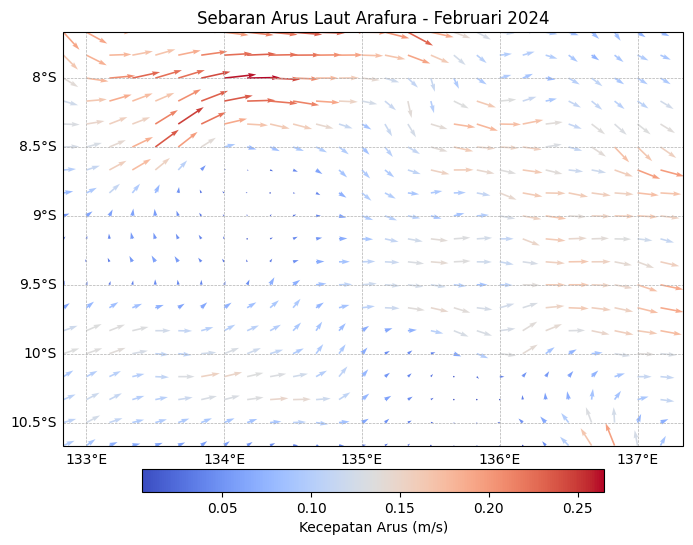

In [ ]:
# Hitung magnitudo kecepatan arus
speed = np.sqrt(uo**2 + vo**2)

# Buat plot peta
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

# Tambahkan garis pantai dan daratan
ax.add_feature(cfeature.LAND, color="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

# Tambahkan vektor arus laut
q = ax.quiver(lon, lat, uo, vo, speed, scale=5, cmap="coolwarm")

# Tambahkan colorbar untuk kecepatan arus
cbar = fig.colorbar(q, ax=ax, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Kecepatan Arus (m/s)")

    # Tambahkan grid koordinat
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)

    # Hilangkan label di kanan dan atas
gl.right_labels = False
gl.top_labels = False

# Tambahkan judul
plt.title("Sebaran Arus Laut Arafura - Februari 2024")
plt.show()

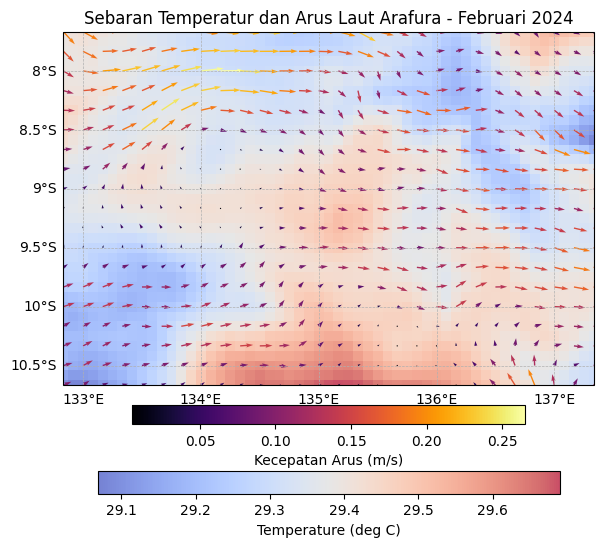

In [ ]:

# Menentukan indeks waktu untuk Januari 2020
time_index = 0  # Pastikan ini didefinisikan sebelum digunakan

# Memilih data suhu permukaan laut (depth=0) untuk Januari 2020
t_feb = ds4["thetao"].isel(time=time_index, depth=0)

t_feb = t_feb.interpolate_na(dim="latitude", method="linear")
t_feb = t_feb.interpolate_na(dim="longitude", method="linear")

# Perbaiki Grid 2D
lon2D, lat2D = np.meshgrid(lon_quiver, lat_quiver)

# Plot peta arus dengan Cartopy
fig, ax = plt.subplots(figsize=(10, 6), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon.min(), lon.max(), lat.min(), lat.max()], crs=ccrs.PlateCarree())

# Tambahkan latar belakang kecepatan arus
ax.add_feature(cfeature.NaturalEarthFeature("physical", "land", "10m"), facecolor="gray")
cmap = ax.pcolormesh(lon2D, lat2D, t_jan, cmap="coolwarm", transform=ccrs.PlateCarree(), alpha=0.7, shading='auto')

# Tambahkan garis pantai dan daratan
ax.add_feature(cfeature.LAND, color="lightgray")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)

# Tambahkan vektor arus laut
q = ax.quiver(lon, lat, uo, vo, speed, scale=6, cmap="inferno")

# Tambahkan colorbar untuk kecepatan arus
cbar = plt.colorbar(cmap, ax=ax, orientation="horizontal", fraction=0.05, pad=0.10)
cbar.set_label("Temperature (deg C)")

cbar = fig.colorbar(q, ax=ax, orientation="horizontal", fraction=0.05, pad=0.05)
cbar.set_label("Kecepatan Arus (m/s)")


# Tambahkan grid koordinat
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5)

# Hilangkan label di kanan dan atas
gl.right_labels = False  
gl.top_labels = False 

# Judul
ax.set_title("Sebaran Temperatur dan Arus Laut Arafura - Februari 2024", fontsize=12)

plt.show()